# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Phạm Văn Thắng"  
STUDENT_ID = "25122055" 

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Phạm Văn Thắng (25122055)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\HCMUT\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
row_max = logits.max(axis=1, keepdims=True)
shifted_logits = logits - row_max
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
predicted_classes_n3 = np.argmax(class_probabilities, axis=1)
confidence_scores_n3 = np.max(class_probabilities, axis=1)

correct_mask = predicted_classes_n3 == true_labels
high_confidence_mask = confidence_scores_n3 >= confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho một mẫu xe (một model xe cụ thể) trong bộ dữ liệu 1985 Auto Imports.
2. Ký hiệu missing value trong CSV là dấu `?`.
3. `symboling` là mức đánh giá rủi ro bảo hiểm của xe, có giá trị từ -3 (an toàn) đến 3 (rủi ro cao), do actuary của công ty bảo hiểm gán dựa trên mức độ rủi ro so với giá xe.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)
raw_df.head()

raw_shape: (205, 26)
raw_missing_marker_count: 59


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])

missing_by_column = df_clean.isna().sum().sort_values(ascending=False)
missing_by_column

normalized_losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak_rpm              2
num_doors             2
symboling             0
fuel_type             0
make                  0
wheel_base            0
engine_location       0
drive_wheels          0
body_style            0
aspiration            0
length                0
height                0
width                 0
fuel_system           0
engine_size           0
num_cylinders         0
engine_type           0
curb_weight           0
compression_ratio     0
city_mpg              0
highway_mpg           0
dtype: int64

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

Không nên fill tất cả các cột numeric bằng cùng một giá trị (ví dụ 0 hoặc mean chung) vì mỗi cột có đơn vị, thang đo và ý nghĩa khác nhau

Với `price`, vì đây là biến mục tiêu chính của bài EDA và chỉ thiếu 4 dòng trên tổng số hơn 200 dòng, nên drop các dòng thiếu `price` sẽ hợp lý hơn fill, vì fill giá xe (kể cả bằng mean/median) có thể tạo ra sai lệch nghiêm trọng trong các phân tích về giá sau này.

`normalized_losses` thiếu tới nhiều nên nếu fill bằng mean/median có thể làm giảm phương sai thực tế và làm sai lệch các phân tích liên quan

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).reset_index(drop=True)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("X_auto shape:", X_auto.shape)

analysis_df shape: (199, 26)
X_auto shape: (199, 6)


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
price_index = AUTO_FEATURES.index('price')
price_values = X_auto[:, price_index]

price_z = (price_values - price_values.mean()) / price_values.std()
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.loc[price_outlier_mask, ['make', 'body_style', 'price']]

price_outliers

,make,body_style,price
14,bmw,sedan,30760.0
15,bmw,sedan,41315.0
16,bmw,sedan,36880.0
44,jaguar,sedan,32250.0
45,jaguar,sedan,35550.0
46,jaguar,sedan,36000.0
67,mercedes-benz,sedan,31600.0
68,mercedes-benz,sedan,34184.0
69,mercedes-benz,convertible,35056.0
70,mercedes-benz,sedan,40960.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
engine_vals = analysis_df['engine_size'].to_numpy(dtype=np.float64)
price_vals = analysis_df['price'].to_numpy(dtype=np.float64)
engine_price_corr = np.corrcoef(engine_vals, price_vals)[0, 1]

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

print("engine_price_corr:", engine_price_corr)
price_by_body_style

engine_price_corr: 0.8738869517981515


body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

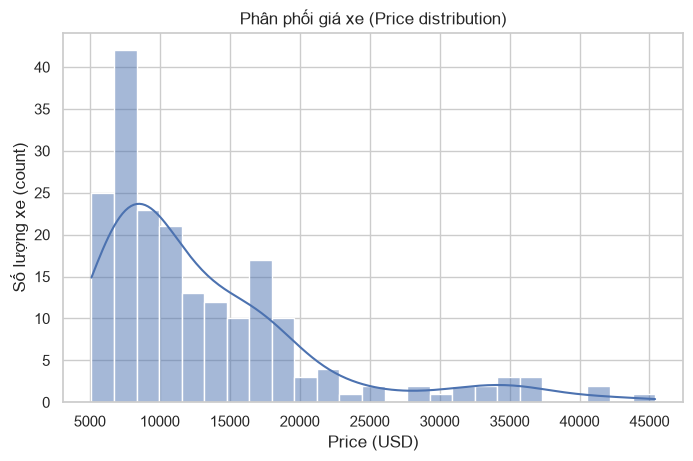

In [20]:
fig, ax = plt.subplots()
sns.histplot(data=analysis_df, x='price', kde=True, bins=25, ax=ax)
ax.set_title('Phân phối giá xe (Price distribution)')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Số lượng xe (count)')
plt.show()

**Nhận xét:** Phân phối price lệch phải rõ rệt (skew ≈ 1.8), phần lớn xe tập trung trong khoảng 7,000–17,000 USD (median ≈ 10,300 USD) trong khi giá trung bình bị kéo lên khoảng 13,200 USD do một số ít xe cao cấp có giá tới 40,000–45,000 USD.

## M2.2 Dataset có cân bằng theo body style không?

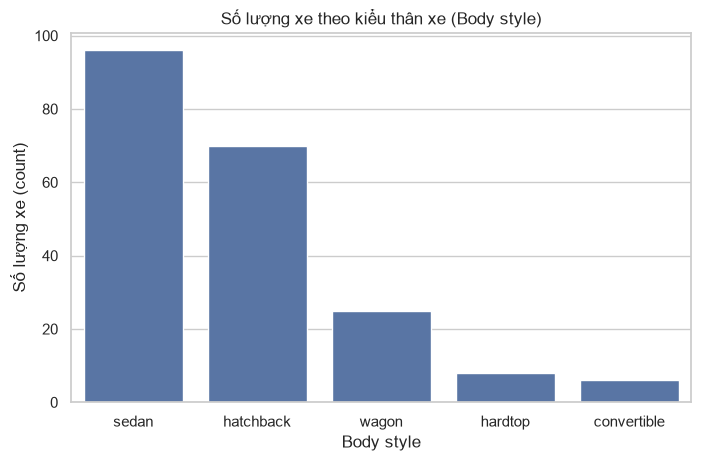

In [21]:
fig, ax = plt.subplots()
order = df_clean['body_style'].value_counts().index
sns.countplot(data=df_clean, x='body_style', order=order, ax=ax)
ax.set_title('Số lượng xe theo kiểu thân xe (Body style)')
ax.set_xlabel('Body style')
ax.set_ylabel('Số lượng xe (count)')
plt.show()

**Nhận xét:** Dataset không cân bằng theo body_style: sedan (96 xe) và hatchback (70 xe) chiếm phần lớn, trong khi convertible (6 xe) và hardtop (8 xe) có rất ít quan sát, nên các kết luận riêng cho hai nhóm này dễ bị nhiễu bởi outlier.

## M2.3 Price khác nhau theo body style ra sao?

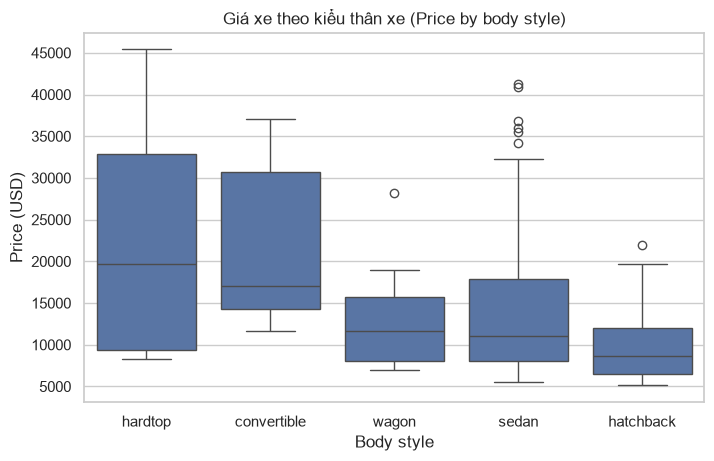

In [22]:
fig, ax = plt.subplots()
order = df_clean.groupby('body_style')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='body_style', y='price', order=order, ax=ax)
ax.set_title('Giá xe theo kiểu thân xe (Price by body style)')
ax.set_xlabel('Body style')
ax.set_ylabel('Price (USD)')
plt.show()

**Nhận xét:** `hardtop` và `convertible` có giá trung vị cao hơn hẳn các kiểu còn lại và cũng có độ phân tán lớn, trong khi `hatchback` có giá trung vị thấp nhất

## M2.4 Engine size liên quan thế nào tới price?

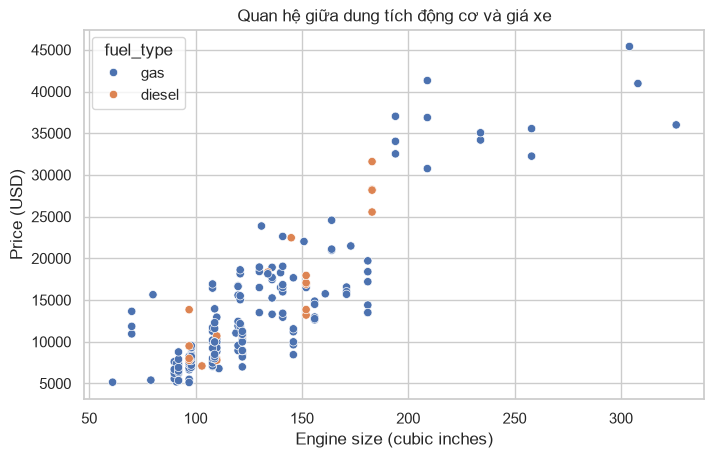

In [23]:
fig, ax = plt.subplots()
sns.scatterplot(data=analysis_df, x='engine_size', y='price', hue='fuel_type', ax=ax)
ax.set_title('Quan hệ giữa dung tích động cơ và giá xe')
ax.set_xlabel('Engine size (cubic inches)')
ax.set_ylabel('Price (USD)')
plt.show()

**Nhận xét:** Engine size và price có tương quan dương khá rõ (khớp với `engine_price_corr` tính ở D5); xe chạy diesel có xu hướng tập trung ở vùng engine size trung bình nhưng giá không thấp hơn nhiều so với xe chạy gas.

## M2.5 Các feature numeric tương quan ra sao?

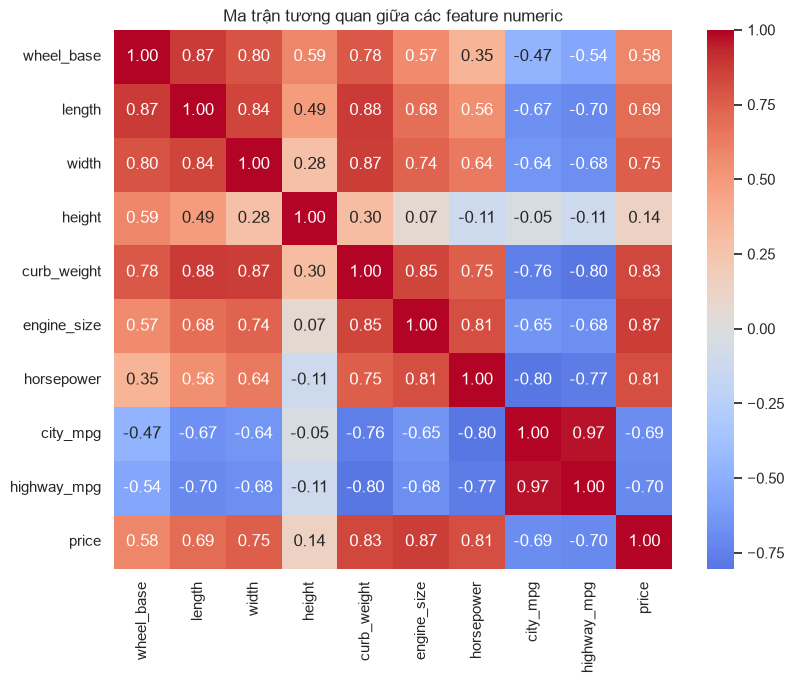

In [24]:
numeric_cols = ['wheel_base', 'length', 'width', 'height', 'curb_weight',
                'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Ma trận tương quan giữa các feature numeric')
plt.show()

**Nhận xét:** `curb_weight`, `engine_size` và `horsepower` tương quan dương mạnh với `price`, trong khi `city_mpg` và `highway_mpg` tương quan âm mạnh với `price` và `curb_weight`

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

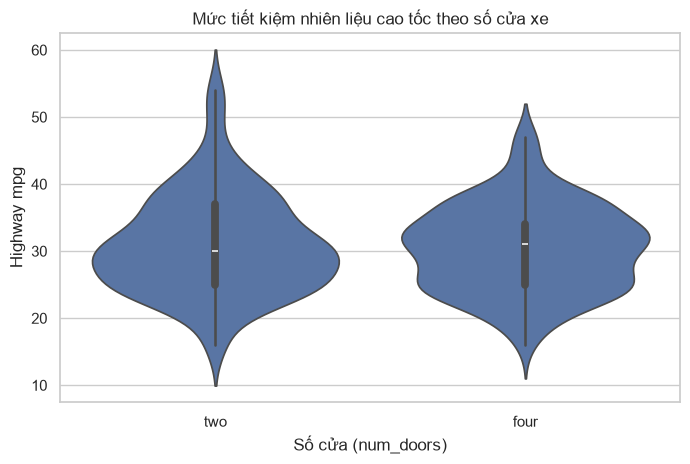

In [25]:
# Câu hỏi: Mức tiêu hao nhiên liệu trên cao tốc (highway_mpg) liên hệ thế nào với
# số cửa xe (num_doors)?
fig, ax = plt.subplots()
sns.violinplot(data=df_clean, x='num_doors', y='highway_mpg', ax=ax)
ax.set_title('Mức tiết kiệm nhiên liệu cao tốc theo số cửa xe')
ax.set_xlabel('Số cửa (num_doors)')
ax.set_ylabel('Highway mpg')
plt.show()

**Nhận xét:** Xe hai cửa (`two`) có xu hướng phân tán rộng hơn về `highway_mpg`, bao gồm cả những xe rất tiết kiệm và rất tốn nhiên liệu, trong khi xe bốn cửa (`four`) có phân phối tập trung hơn quanh mức trung bình.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

Giá xe (`price`) phân phối lệch phải, phần lớn xe có giá dưới 15,000 USD và chỉ một số ít xe cao cấp có giá vượt 30,000 USD.
`Engine_size`, `horsepower` và `curb_weight` đều tương quan dương mạnh với `price`.
`City_mpg` và `highway_mpg` tương quan âm mạnh với cả `price` và `curb_weight`, cho thấy đánh đổi rõ ràng giữa hiệu năng/kích thước xe và mức tiết kiệm nhiên liệu.

Kích thước mẫu nhỏ (205 dòng) khiến các nhóm con (như convertible, 4wd) có rất ít quan sát nên kết luận dễ bị nhiễu bởi outlier; đồng thời dữ liệu chỉ là một lát cắt của thị trường xe nhập khẩu Mỹ năm 1985 nên khó tổng quát hoá cho thị trường xe hiện đại.

`Highway_mpg` tương quan âm với `price`, nhưng điều này không có nghĩa là giá xe cao *gây ra* mức tiêu hao nhiên liệu thấp hơn; thực chất cả hai đều bị chi phối bởi một biến ẩn là kích thước/công suất động cơ.

Có hãng nào định giá cao/thấp bất thường so với thông số kỹ thuật hay không?
